# 00 – Datenaufbereitung

Dieses Notebook wird **einmalig** ausgeführt und erzeugt die aufbereiteten Datensätze unter `data/processed/`.

**Schritte:**
1. Rohdaten laden und Zeitbereiche prüfen
2. Auf gemeinsamen Zeitraum trimmen
3. Mergen (PV + Wetter + Einstrahlung)
4. Drop irrelevanter Features
5. Check for missing values
7. Vollständigen Feature-Datensatz speichern → `features.csv`


In [1]:
import sys
from pathlib import Path

import pandas as pd

# Projekt-Root ins sys.path aufnehmen (notebooks/ liegt eine Ebene unterhalb)
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.preprocessing import (
    load_pv_data,
    load_weather_data,
    load_irradiance_data,
    clip_to_common_range,
)


## 1. Rohdaten laden

In [2]:
pv_raw      = load_pv_data()
weather_raw = load_weather_data()
irr_raw     = load_irradiance_data()

print(f"PV:           {pv_raw['timestamp'].min()}  →  {pv_raw['timestamp'].max()}   ({len(pv_raw):>7,} Zeilen)")
print(f"Wetter:       {weather_raw['timestamp'].min()}  →  {weather_raw['timestamp'].max()}   ({len(weather_raw):>7,} Zeilen)")
print(f"Einstrahlung: {irr_raw['timestamp'].min()}  →  {irr_raw['timestamp'].max()}  ({len(irr_raw):>7,} Zeilen)")

PV:           2022-02-07 14:00:00  →  2025-06-16 23:45:00   (117,636 Zeilen)
Wetter:       2020-01-01 00:00:00  →  2025-10-05 23:00:00   ( 50,520 Zeilen)
Einstrahlung: 2022-02-07 14:00:00+00:00  →  2025-06-16 23:45:00+00:00  (117,640 Zeilen)


## 2. Gemeinsamen Zeitraum bestimmen & trimmen

In [3]:
pv, weather, irr = clip_to_common_range(pv_raw, weather_raw, irr_raw)

common_start = pv["timestamp"].min()
common_end   = pv["timestamp"].max()
print(f"Gemeinsamer Zeitraum: {common_start}  →  {common_end}")
print(f"PV: {len(pv):,} | Wetter: {len(weather):,} | Einstrahlung: {len(irr):,} Zeilen")


Gemeinsamer Zeitraum: 2022-02-07 15:00:00  →  2025-06-16 23:45:00
PV: 117,632 | Wetter: 29,409 | Einstrahlung: 117,632 Zeilen


## 3. Mergen (PV + Wetter + Einstrahlung)

### `merge_features` – Zusammenführen der drei Datenquellen

Die Funktion kombiniert PV- (15-min, lokale naive Zeit), Wetter- (stündlich, UTC-naive) und Einstrahlungsdaten (15-min, UTC-aware) zu einem einheitlichen DataFrame.

**DST-sichere Verarbeitung:** Alle Zeitstempel werden intern nach UTC konvertiert, bevor die Merges stattfinden. Dadurch werden zwei Logger-Artefakte korrekt behandelt:

- **Phantom-Timestamps (2023-03-26):** Der PV-Logger hat für die nicht-existente Stunde 02:00–02:45 (Sommerzeit-Umstellung) Einträge aufgezeichnet. `tz_localize(..., nonexistent="NaT")` markiert diese als NaT; anschließendes `dropna` entfernt sie.
- **Fehlende Zeilen (2024-03-31):** Der PV-Logger hat die nicht-existente Stunde korrekt übersprungen → Lücken werden nach dem Merge per Reindex + Auffüllen geschlossen.
- **Rückumstellung (Oktober):** Ambiguous timestamps (02:00–02:59 erscheinen doppelt) werden per `ambiguous="NaT"` aufgelöst.

Die Wetterdaten (Open-Meteo) haben kein Zeitzonen-Suffix, sind aber UTC — DST-Problematik entfällt hier, da UTC keine Sommerzeitumstellung kennt.

Nach dem Merge wird UTC zurück in naive Lokalzeit (`Europe/Berlin`) konvertiert.

In [4]:
def merge_features(
    pv_df: pd.DataFrame,
    weather_df: pd.DataFrame,
    irr_df: pd.DataFrame,
    local_tz: str = "Europe/Berlin",
) -> pd.DataFrame:
    """Merge PV, weather and irradiance data. Returns UTC-aware timestamps."""
    base = pv_df.sort_values("timestamp").reset_index(drop=True)

    # PV: naive Lokalzeit → UTC
    # nonexistent="NaT": entfernt Phantom-Timestamps bei Vorwärtsumstellung (z.B. 2023-03-26)
    # ambiguous="NaT": entfernt ambiguous Timestamps bei Rückumstellung (Oktober)
    base["timestamp"] = (
        base["timestamp"]
        .dt.tz_localize(local_tz, nonexistent="NaT", ambiguous="NaT")
        .dt.tz_convert("UTC")
    )
    base = base.dropna(subset=["timestamp"])

    # Wetterdaten: stündlich, UTC-naive (Open-Meteo liefert immer UTC ohne Zeitzonen-Suffix)
    # → tz_localize("UTC"), dann lineare Interpolation auf 15-Minuten-Raster
    w_cols = ["timestamp", "temperature_2m", "cloud_cover", "cloud_cover_low",
              "relative_humidity_2m"]
    w = (
        weather_df[w_cols]
        .sort_values("timestamp")
        .set_index("timestamp")
        .resample("15min")
        .interpolate(method="linear")
        .reset_index()
    )
    w["timestamp"] = w["timestamp"].dt.tz_localize("UTC")

    base = pd.merge_asof(base, w, on="timestamp",
                         direction="nearest", tolerance=pd.Timedelta("15min"))

    # Einstrahlungsdaten: bereits UTC-aware → direkt merge_asof
    irr = irr_df[["timestamp", "ghi_cloudy_sky", "ghi_clear_sky"]].copy()
    irr = irr.sort_values("timestamp").reset_index(drop=True)
    base = pd.merge_asof(base, irr, on="timestamp",
                         direction="nearest", tolerance=pd.Timedelta("15min"))

    # Gibt UTC-aware Timestamps zurück (Reindex und Lückenschluss erfolgen in cell-9)
    return base

In [5]:
df = merge_features(pv, weather, irr)
df["temperature_2m"] = df["temperature_2m"].round(1)
print(f"Nach merge_features(): {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten")

# Vollständiges 15-min-Raster in UTC sicherstellen
# (Reindex in UTC vermeidet nicht-existente Lokalzeit-Slots bei Vorwärtsumstellung)
full_idx_utc = pd.date_range(df["timestamp"].min(), df["timestamp"].max(),
                              freq="15min", tz="UTC")
rows_before = len(df)
df = (
    df.set_index("timestamp")
      .reindex(full_idx_utc)
      .rename_axis("timestamp")
      .reset_index()
)
print(f"Nach Reindex (UTC): {df.shape[0]:,} Zeilen (+{df.shape[0] - rows_before} neue Slots)")

# PV-Lücken (DST-Übergänge, Logger-Ausfälle) → 0
df["Solarproduktion"] = df["Solarproduktion"].fillna(0)

# Wetter / Einstrahlung → lineare Interpolation der wenigen Lücken (max 2h = 8 Slots)
interp_cols = ["temperature_2m", "cloud_cover_low", "ghi_cloudy_sky", "ghi_clear_sky"]
df[interp_cols] = df[interp_cols].interpolate(method="linear", limit=8)

print(f"Fehlende Werte nach Auffüllen:")
print(df[["Solarproduktion"] + interp_cols].isna().sum())

# UTC → naive Lokalzeit (am Ende, nach Reindex → keine nicht-existenten Slots)
# Bei Rückumstellung erzeugt UTC→Lokal doppelte naive Timestamps (02:00–02:45 erscheinen 2×);
# keep="first" behält die CEST-Seite (UTC+2) und verwirft die CET-Seite (UTC+1).
df["timestamp"] = df["timestamp"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)
rows_pre_dedup = len(df)
df = df.drop_duplicates(subset=["timestamp"], keep="first").reset_index(drop=True)
if len(df) < rows_pre_dedup:
    print(f"Rückumstellungs-Duplikate entfernt: {rows_pre_dedup - len(df)} Zeilen")

# DST-Verifikation
phantom = df[df["timestamp"].between("2023-03-26 01:30", "2023-03-26 03:30")]
assert not phantom["timestamp"].between("2023-03-26 02:00", "2023-03-26 02:45").any(), \
    "Phantom-Timestamps 2023-03-26 noch vorhanden!"

gap_filled = df[df["timestamp"].between("2024-03-31 01:30", "2024-03-31 03:30")]
assert "2024-03-31 03:00:00" in gap_filled["timestamp"].astype(str).values, \
    "Lücke 2024-03-31 nicht gefüllt!"

dst_back = df[df["timestamp"].between("2023-10-29 01:30", "2023-10-29 03:30")]
assert dst_back["timestamp"].is_unique, "Doppelte Timestamps bei Rückumstellung!"

print("DST-Checks bestanden.")
df.head(3)

Nach merge_features(): 117,608 Zeilen × 22 Spalten
Nach Reindex (UTC): 117,632 Zeilen (+24 neue Slots)
Fehlende Werte nach Auffüllen:
Solarproduktion    0
temperature_2m     3
cloud_cover_low    3
ghi_cloudy_sky     0
ghi_clear_sky      0
dtype: int64
Rückumstellungs-Duplikate entfernt: 12 Zeilen
DST-Checks bestanden.


,timestamp,Ladezustand,Batterie (Laden),Batterie (Entladen),Netzeinspeisung,Netzbezug,Solarproduktion Tracker 1,Solarproduktion Tracker 2,Solarproduktion Tracker 3,Solarproduktion,...,Wallbox (ID 0) Netzbezug,Wallbox (ID 0) Solarladeleistung,Wallbox Gesamtladeleistung,Σ Verbrauch,temperature_2m,cloud_cover,cloud_cover_low,relative_humidity_2m,ghi_cloudy_sky,ghi_clear_sky
0,2022-02-07 15:00:00,23.0,0.0,0.0,5.0,12.0,72.0,146.0,0.0,218.0,...,NaN,NaN,NaN,220.0,NaN,NaN,NaN,NaN,54.51,75.92
1,2022-02-07 15:15:00,23.0,0.0,0.0,2.0,2.0,65.0,132.0,0.0,197.0,...,NaN,NaN,NaN,194.0,NaN,NaN,NaN,NaN,50.70,70.61
2,2022-02-07 15:30:00,23.0,0.0,0.0,2.0,2.0,66.0,135.0,0.0,201.0,...,NaN,NaN,NaN,198.0,NaN,NaN,NaN,NaN,46.48,64.74


## 4. Drop irrelevanter features

In [6]:
FEATURE_COLS = [
    "timestamp",
    "Solarproduktion",  # pv_data
    "temperature_2m", "cloud_cover_low",  # weather
    "ghi_cloudy_sky", "ghi_clear_sky",  # irradiance
]

cols_before = df.shape[1]  # number of columns before

df = df[FEATURE_COLS]

print(f"Gedroppt: {cols_before - df.shape[1]} Columns  →  {df.shape[1]:,} Columns verbleiben")


Gedroppt: 16 Columns  →  6 Columns verbleiben


## 5. Check for missing values

In [7]:
gap_mask = df["timestamp"].diff() > pd.Timedelta("15min")
gaps = df.loc[gap_mask, "timestamp"]

gaps.head()

4556     2022-03-27 03:00:00
39496    2023-03-26 03:00:00
75108    2024-03-31 03:00:00
110048   2025-03-30 03:00:00
Name: timestamp, dtype: datetime64[us]

--> Keine Missing Values außer bei Zeitumstellung!

## 6. Vollständigen Feature-Datensatz speichern

In [8]:
out_dir = PROJECT_ROOT / "data" / "processed"
out_dir.mkdir(parents=True, exist_ok=True)

features_path = out_dir / "merged.csv"
df.to_csv(features_path, index=False)
print(f"Gespeichert: './data/processed/merged.csv'")
print(f"  {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten")
print(f"  Zeitraum: {df['timestamp'].min()} → {df['timestamp'].max()}")

Gespeichert: './data/processed/merged.csv'
  117,620 Zeilen × 6 Spalten
  Zeitraum: 2022-02-07 15:00:00 → 2025-06-16 23:45:00


---
## Folienentwurf – Folie 1: Merge der Datenquellen

**Titel:** Merge der Daten mit Interpolation der Wetterdaten

**Drei Datenquellen – drei Zeitformate:**
- **PV-Daten:** 15-min-Auflösung, lokale Naive-Zeit (kein Zeitzonen-Info)
- **Wetterdaten:** stündlich, UTC-naive (Open-Meteo liefert kein Zeitzonen-Suffix, Daten sind UTC)
- **Einstrahlungsdaten:** 15-min-Auflösung, UTC-aware (`+00:00`)

**Merge-Strategie:**
- Alle Quellen werden intern nach UTC konvertiert
- Zusammenführung per `merge_asof` (nächster Nachbar, Toleranz 15 min)
- Wetterdaten: **lineare Interpolation** von stündlich → 15-min-Raster
- Reindex auf vollständiges UTC-15-min-Gitter → alle Lücken geschlossen

→ Ergebnis: 117.620 Zeilen × 6 Spalten, Zeitraum 07.02.2022 – 16.06.2025 (ca. 3,5 Jahre)

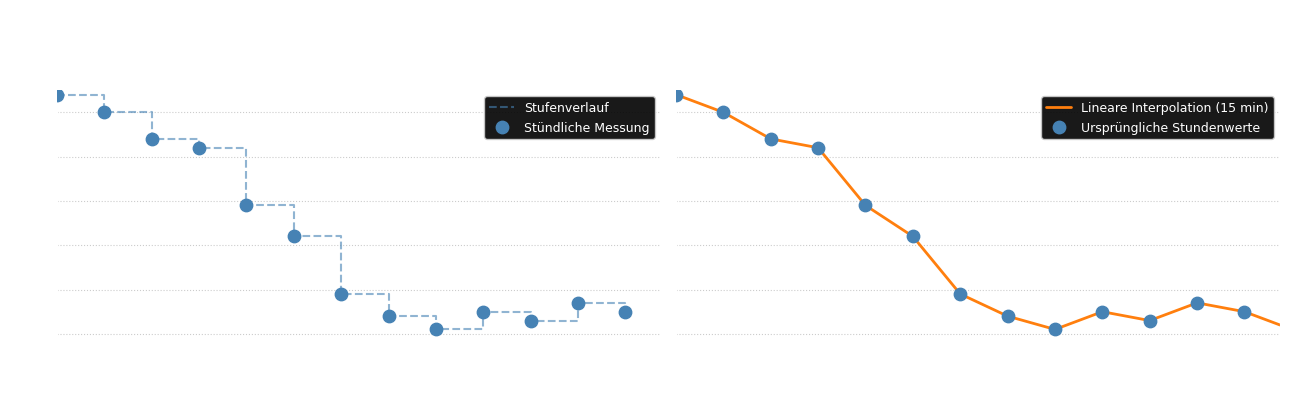

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from pathlib import Path

# Beispieltag mit guter Bewölkungsdynamik: 13.11.2022
features = pd.read_csv(Path('../data/processed/merged.csv'), parse_dates=['timestamp'])
day = features[features['timestamp'].dt.date == pd.Timestamp('2022-11-13').date()]
day = day[day['timestamp'].dt.hour.between(6, 18)].copy()

# Stündliche Rohdaten simulieren (jede 4. Zeile = Original-Wetterstunde)
hourly = day[day['timestamp'].dt.minute == 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor='white', sharey=True)
fig.suptitle(
    'Merge der Daten mit Interpolation der Wetterdaten\n'
    'Beispiel: Tiefe Bewölkung (cloud_cover_low) am 13.11.2022',
    fontsize=12, fontweight='bold'
)

# ── Links: Rohdaten stündlich ──────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('white')
ax.step(hourly['timestamp'], hourly['cloud_cover_low'],
        where='post', color='steelblue', linewidth=1.5, linestyle='--', alpha=0.6, label='Stufenverlauf')
ax.scatter(hourly['timestamp'], hourly['cloud_cover_low'],
           s=80, color='steelblue', zorder=5, label='Stündliche Messung')
ax.set_title('Wetterdaten – Original (stündlich)', fontsize=11)
ax.set_ylabel('Tiefe Bewölkung [%]', fontsize=10)
ax.set_xlabel('Uhrzeit', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.set_xlim(day['timestamp'].min(), day['timestamp'].max())
ax.set_ylim(-2, 55)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')

# ── Rechts: Interpoliert auf 15-min ───────────────────────────────────────
ax = axes[1]
ax.set_facecolor('white')
ax.plot(day['timestamp'], day['cloud_cover_low'],
        color='tab:orange', linewidth=2.0, label='Lineare Interpolation (15 min)')
ax.scatter(hourly['timestamp'], hourly['cloud_cover_low'],
           s=80, color='steelblue', zorder=5, label='Ursprüngliche Stundenwerte')
ax.set_title('Nach linearer Interpolation (15-min-Raster)', fontsize=11)
ax.set_xlabel('Uhrzeit', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.set_xlim(day['timestamp'].min(), day['timestamp'].max())
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')

plt.tight_layout()
plt.show()

---
## Folienentwurf – Folie 2: Zeitumstellung & fehlende Werte

**Titel:** Zeitumstellung & fehlende Werte

**Zeitumstellung – zwei Fälle (immer nachts, PV-Produktion = 0):**

- **Vorwärtsumstellung** (z. B. 26.03.2023, 02:00 → 03:00):  
  Der PV-Logger hat Phantom-Timestamps für 02:00–02:45 aufgezeichnet (diese Stunde existiert nicht).  
  Lösung: `tz_localize(nonexistent="NaT")` → NaT → `dropna` entfernt diese Zeilen.  
  Da die Umstellung nachts stattfindet, ist die Solarproduktion ohnehin 0 – kein Datenverlust.

- **Rückwärtsumstellung** (Oktober, 03:00 → 02:00):  
  02:00–02:45 erscheint doppelt (CEST + CET).  
  Lösung: `drop_duplicates(keep="first")` → CEST-Seite behalten, CET-Seite verworfen.  
  Auch hier: Nachtumstellung, Produktion = 0, kein relevanter Datenverlust.

- Reindex auf vollständiges **UTC**-Gitter → keine nicht-existenten Lokalzeit-Slots entstehen

**Fehlende Werte:**

- Ursprünglich fehlende Tage → **durch erneuten Datenexport behoben** (Rohdaten waren vorhanden)
- Nach Export: **keine fehlenden Werte** in den Kernspalten  
  DST-Lücken (nachts): PV → 0-Fill, Wetter/Einstrahlung → lineare Interpolation
- Lag-Feature (`Solarproduktion_lag_96`): erzeugt ~96 NaN-Zeilen an jeder Split-Grenze  
  → `dropna()` vor Training – **vernachlässigbar** bei 117.620 Zeilen Gesamtdatensatz (~0,08 %)